In [57]:
%load_ext autoreload
%autoreload 2
    
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import sys
import os

# --- Imports from your custom library ---
# Ensure '../' is in the path to find conformalHDC
sys.path.append('../') 
try:
    from conformal_inference.models import *
    from conformal_inference.methods import *
    from conformal_inference.utils import *
except ImportError:
    print("Warning: conformalHDC modules not found. Ensure '../' is in path.")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def set_seed(seed=123):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

SEED = 123
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [4]:
print("Fetching ISOLET data...")
iso = fetch_openml('isolet', version=1, as_frame=False)
X = iso['data'].astype(np.float32)  # (N, 617)
y = iso['target']

# Map labels 'A'..'Z' to 0..25
classes = sorted(np.unique(y).tolist())
label_to_id = {c: i for i, c in enumerate(classes)}
y_int = np.array([label_to_id[s] for s in y], dtype=np.int64)

# Quantization Constants
LEVELS = 21 
Xmin = X.min(axis=0)
Xmax = X.max(axis=0)
rng  = np.maximum(Xmax - Xmin, 1e-8)

def quantize_to_levels(Xf: np.ndarray, levels: int = LEVELS) -> np.ndarray:
    Z = (Xf - Xmin) / rng
    L = np.clip(np.round(Z * (levels - 1)), 0, levels - 1).astype(np.int64)
    return L

# Quantize entire dataset first
L_all = quantize_to_levels(X)
print("Quantization complete on ISOLET data.")

Fetching ISOLET data...
Quantization complete on ISOLET data.


In [62]:
ID_CLASSES = list(range(23)) 
OOD_CLASSES = list(range(23, 26)) # X,Y,Z

id_mask = np.isin(y_int, ID_CLASSES)
ood_mask = np.isin(y_int, OOD_CLASSES)

X_id, y_id = L_all[id_mask], y_int[id_mask]
X_ood, y_ood = L_all[ood_mask], y_int[ood_mask]

# --- Splitting ID Data ---
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_id, y_id, test_size=0.05, random_state=SEED, stratify=y_id
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_full, y_train_full, test_size=0.4, random_state=SEED, stratify=y_train_full 
)

print(f"ID Train shape: {X_train.shape}")
print(f"ID Calib shape: {X_cal.shape}")
print(f"ID Test shape:  {X_test.shape}")
print(f"OOD Data shape: {X_ood.shape}")

ID Train shape: (3931, 617)
ID Calib shape: (2621, 617)
ID Test shape:  (345, 617)
OOD Data shape: (900, 617)


In [63]:
# Convert to Tensors
def to_loader(X_np, y_np, batch_size=128, shuffle=False):
    dset = TensorDataset(torch.from_numpy(X_np), torch.from_numpy(y_np))
    return DataLoader(dset, batch_size=batch_size, shuffle=shuffle)

ld_train = to_loader(X_train, y_train, shuffle=True)
ld_cal   = to_loader(X_cal, y_cal)
ld_test  = to_loader(X_test, y_test)
ld_ood   = to_loader(X_ood, y_ood)

In [64]:
@torch.no_grad()
def bipolar_sign(x):
    return torch.where(x >= 0, torch.ones_like(x), -torch.ones_like(x))

def _rand_bip(shape, device=None):
    device = device or DEVICE
    r = torch.randint(0, 2, shape, device=device, dtype=torch.int8)
    return r.float().mul_(2).sub_(1)

def make_im_cim(F, Levels, D, device=None):
    device = device or DEVICE
    # iM: Random Orthogonal
    iM = _rand_bip((F, D), device=device)
    
    # CiM: Correlated (Progressive bit flip)
    base = _rand_bip((D,), device=device)
    perm = torch.randperm(D, device=device)
    CiM = torch.empty((Levels, D), device=device, dtype=torch.float32)
    for l in range(Levels):
        k = (l * D) // max(1, Levels - 1)
        hv = base.clone()
        if k > 0:
            hv[perm[:k]] = -hv[perm[:k]]
        CiM[l] = hv
    return iM, CiM

@torch.no_grad()
def encode_batch(L_batch, iM, CiM, block_features=64):
    B, F_dim = L_batch.shape
    D = iM.shape[1]
    hv_sum = torch.zeros((B, D), device=iM.device)
    
    # Block processing to save memory
    for f0 in range(0, F_dim, block_features):
        f1 = min(f0 + block_features, F_dim)
        # Gather CiM vectors for the values in this block
        vals = L_batch[:, f0:f1].long().to(iM.device)
        CiM_sel = CiM[vals] # [B, block, D]
        iM_blk  = iM[f0:f1].unsqueeze(0) # [1, block, D]
        # Bind & Bundle
        hv_sum.add_((CiM_sel * iM_blk).sum(dim=1))
        
    return bipolar_sign(hv_sum)

@torch.no_grad()
def get_hvs_labels(loader, iM, CiM):
    all_hvs, all_lbls = [], []
    for X_b, y_b in loader:
        hvs = encode_batch(X_b, iM, CiM)
        all_hvs.append(hvs.cpu().numpy())
        all_lbls.append(y_b.numpy())
    return np.concatenate(all_hvs), np.concatenate(all_lbls)

In [65]:
DIM = 10_000
F = X.shape[1] # 617 features

print("Initializing HDC memories...")
iM, CiM = make_im_cim(F, LEVELS, DIM)

print("Encoding data to Hypervectors...")
train_hvs, train_y = get_hvs_labels(ld_train, iM, CiM)
cal_hvs, cal_y = get_hvs_labels(ld_cal, iM, CiM)
test_hvs, test_y = get_hvs_labels(ld_test, iM, CiM)
ood_hvs, ood_y = get_hvs_labels(ld_ood, iM, CiM)

min_ood = min(len(ood_hvs), len(test_hvs))
ood_hvs, ood_y = ood_hvs[:min_ood], ood_y[:min_ood]

print(f"Encoded shapes: Train{train_hvs.shape}, Cal{cal_hvs.shape}, Test{test_hvs.shape}")

Initializing HDC memories...
Encoding data to Hypervectors...
Encoded shapes: Train(3931, 10000), Cal(2621, 10000), Test(345, 10000)


In [66]:
print("Building Conformal Prototypes...")
# Simple summation of training HVs per class
n_classes_id = len(ID_CLASSES)
protos_conf = np.zeros((n_classes_id, DIM))
for i, lbl in enumerate(ID_CLASSES):
    idx = np.where(train_y == lbl)[0]
    if len(idx) > 0:
        protos_conf[i] = np.sign(np.sum(train_hvs[idx], axis=0))
print(f"Conformal prototypes built with {len(train_hvs)} hvs, shape: {protos_conf.shape}")

Building Conformal Prototypes...
Conformal prototypes built with 3931 hvs, shape: (23, 10000)


In [67]:
print("Building Vanilla Prototypes (Train + Calib)...")
X_vanilla = np.concatenate([train_hvs, cal_hvs])
y_vanilla = np.concatenate([train_y, cal_y])
protos_vanilla = np.zeros((n_classes_id, DIM))
for i, lbl in enumerate(ID_CLASSES):
    idx = np.where(y_vanilla == lbl)[0]
    if len(idx) > 0:
        protos_vanilla[i] = np.sign(np.sum(X_vanilla[idx], axis=0))
print(f"Conformal prototypes built with {len(X_vanilla)} hvs, shape: {protos_vanilla.shape}")

Building Vanilla Prototypes (Train + Calib)...
Conformal prototypes built with 6552 hvs, shape: (23, 10000)


In [68]:
# Initialize Conformal Object
chdc = ConformalHDC(protos_conf, ID_CLASSES)
full_chdc = ConformalHDC(protos_vanilla, ID_CLASSES)
ALPHA = 0.05
SCORE_TYPES = ["sim", "ratio", "discount", "inverse_quantile"]

In [69]:
results = []

print("\n--- Starting Conformal Tests ---")
for stype in SCORE_TYPES:
    print(f"Processing score type: {stype}")
    
    chdc.compute_calib_scores(cal_hvs, cal_y, score_type=stype)
    
    # 1. Set-Valued Prediction (Marginal)
    sets = chdc.set_valued_CP(test_hvs, ALPHA, marginal=True)
    sizes = [len(s) for s in sets]
    covered = [1 if y in s else 0 for y, s in zip(test_y, sets)]
    
    # 2. Point-Valued Prediction (Efficient)
    preds_pt = full_chdc.point_valued_CP(test_hvs, score_type=stype)
    acc_pt = accuracy_score(test_y, preds_pt)
    
    # 3. OOD Detection (Marginal p-values)
    p_in = chdc.get_max_p_value(test_hvs, marginal=True)
    p_ood = chdc.get_max_p_value(ood_hvs, marginal=True)
    
    y_true_roc = np.concatenate([np.ones(len(p_in)), np.zeros(len(p_ood))])
    y_scores_roc = np.concatenate([p_in, p_ood])
    auroc = roc_auc_score(y_true_roc, y_scores_roc)
    
    results.append({
        "Method": f"Conformal ({stype})",
        "Set Cov": np.mean(covered),
        "Set Size": np.mean(sizes),
        "Point Acc": acc_pt,
        "OOD AUROC": auroc
    })

# --- Vanilla HDC Baseline ---
print("Running Vanilla HDC Baseline...")
# Cosine Similarity
def cosine_sim(A, B):
    # A: (N, D), B: (C, D)
    normA = np.linalg.norm(A, axis=1, keepdims=True)
    normB = np.linalg.norm(B, axis=1, keepdims=True).T
    epsilon = 1e-8
    return (A @ B.T) / (normA * normB + epsilon)

sims = cosine_sim(test_hvs, protos_vanilla)
preds_vanilla_idx = np.argmax(sims, axis=1)
preds_vanilla = np.array([ID_CLASSES[i] for i in preds_vanilla_idx])
acc_vanilla = accuracy_score(test_y, preds_vanilla)

results.append({
    "Method": "Vanilla HDC",
    "Set Cov": np.nan,
    "Set Size": np.nan,
    "Point Acc": acc_vanilla,
    "OOD AUROC": np.nan 
})


--- Starting Conformal Tests ---
Processing score type: sim
Processing score type: ratio
Processing score type: discount
Processing score type: inverse_quantile
Running Vanilla HDC Baseline...



=== Experiment Results (Alpha=0.05) ===


,Method,Set Cov,Set Size,Point Acc,OOD AUROC
0,Conformal (sim),0.9304,4.0667,0.913,0.7327
1,Conformal (ratio),0.9420,3.4058,0.913,0.7380
2,Conformal (discount),0.9304,3.1797,0.913,0.7585
3,Conformal (inverse_quantile),0.9652,1.9420,0.913,0.4843
4,Vanilla HDC,NaN,NaN,0.913,NaN


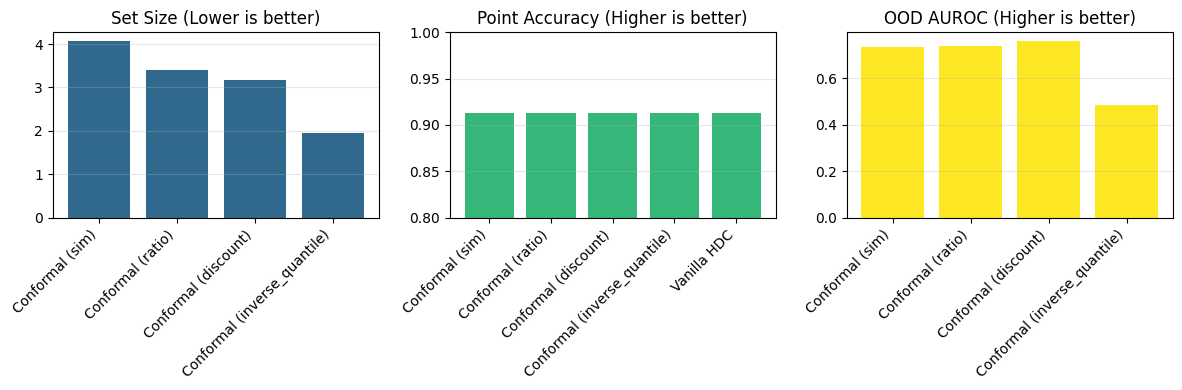

In [70]:
df_res = pd.DataFrame(results)
print(f"\n=== Experiment Results (Alpha={ALPHA}) ===")
display(df_res.round(4))

# Filter vanilla for specific plots
df_methods = df_res[df_res['Method'] != 'Vanilla HDC']

plt.figure(figsize=(12, 4))

# Plot Set Size
plt.subplot(1, 3, 1)
plt.bar(df_methods['Method'], df_methods['Set Size'], color='#31688e')
plt.title("Set Size (Lower is better)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Plot Point Accuracy
plt.subplot(1, 3, 2)
plt.bar(df_res['Method'], df_res['Point Acc'], color='#35b779')
plt.title("Point Accuracy (Higher is better)")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Plot OOD AUROC
plt.subplot(1, 3, 3)
plt.bar(df_methods['Method'], df_methods['OOD AUROC'], color='#fde725')
plt.title("OOD AUROC (Higher is better)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()